In [1]:
import numpy as np
import pandas as pd

### Day 1 — Bird Diversity & Habitat Analysis

In [ ]:
np.random.seed(42)

sites = ["East Kolkata Wetlands", "Sundarban Fringe", "Nalban", "Santragachi"]
species = ["Egret", "Kingfisher", "Heron", "Cormorant", "Ibis", "Pied Hornbill"]

dates = pd.date_range("2025-01-01", "2025-06-01", freq="MS")

rows = []

for date in dates:
    for site in sites:
        for sp in species:
            rows.append({
                "date": date,
                "site": site,
                "species": sp,
                "count": np.random.poisson(
                    np.random.uniform(5, 30)
                ),
                "observation_hours": np.random.uniform(2, 8)
            })

birds = pd.DataFrame(rows)

# Introduce some missing observations
missing_idx = np.random.choice(
    birds.index,
    size=12,
    replace=False
)

birds.loc[missing_idx, "count"] = np.nan

birds.head()

In [ ]:
birds.info()
birds.describe()

In [ ]:
birds['count'].unique()
birds[birds['count'].isna()]
birds.fillna(birds['count'].mean(), inplace=True)

In [ ]:
birds['month'] = birds['date'].dt.month
birds['day_name'] = birds['date'].dt.day_name()
birds['density'] = birds['count'] / birds['observation_hours']
birds.head()

In [ ]:
birds[birds['count']>birds['count'].mean()]
birds.query('species == "Egret" | species =="Kingfisher" | species == "Heron" | species == "Cormorant" | species == "Ibis"').where(birds['count'] > birds['count'].mean()).dropna()
birds.query('species == "Kingfisher"').where(birds['site'] == 'Nalban').dropna().sort_values(by='date',ascending=False)

In [ ]:
birds.where(birds['observation_hours']>=birds['observation_hours'].quantile(0.9)).dropna()
birds['observation_hours'].quantile([0.25,0.5,0.75,0.9])

In [ ]:
birds.groupby(['site','species'])['count'].agg(['min','max','mean','sum']).sort_values(by=['site','sum'] ,ascending=[True,False] )
birds.groupby('species')['count'].agg(['max','min','std'])
birds.groupby(['site','month'])['count'].agg(['sum']).sort_values(by=['site','sum'],ascending=[True,False])

In [ ]:
birds_pivot = pd.pivot_table(birds, index='site', columns='species',values='count',aggfunc='sum')
birds_pivot

In [ ]:
ovser_pivot = pd.pivot_table(birds,index='site',columns='species',values='observation_hours',aggfunc='mean')
ovser_pivot

### Day 2 — Water Quality & Pollution Analysis

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(24)

stations = ["Hooghly_A", "Hooghly_B", "Damodar_A", "Damodar_B", "Rupnarayan"]
months = pd.date_range("2025-01-01", "2025-08-01", freq="MS")

rows = []

for month in months:
    for station in stations:
        rows.append({
            "date": month,
            "station": station,
            "temperature": np.random.normal(27, 3),
            "dissolved_oxygen": np.random.normal(6, 1.2),
            "bod": np.random.normal(4, 1.5),
            "nitrate": np.random.normal(3.5, 1.5),
            "sampling_depth": np.random.uniform(0.5, 3.0)
        })

water = pd.DataFrame(rows)

# Introduce realistic missing measurements
missing_idx = np.random.choice(
    water.index,
    size=10,
    replace=False
)

water.loc[missing_idx, "dissolved_oxygen"] = np.nan
water.loc[
    np.random.choice(water.index, 6, replace=False),
    "nitrate"
] = np.nan

water.head()

In [ ]:
water.info()
water.describe()

In [ ]:
# finding null values and replace them with mean
water[water['dissolved_oxygen'].isna()]
water.fillna(value={
    'dissolved_oxygen': water['dissolved_oxygen'].mean(),
    'bod' : water['bod'].mean(),
    'nitrate' : water['nitrate'].mean()
},inplace=True)

In [ ]:
# seperating months in a new column
water['month'] = water['date'].dt.month
water

In [ ]:
water.groupby('month')[['dissolved_oxygen','bod','nitrate']].agg(['min','max','mean'])

In [ ]:
water.groupby('month')[['dissolved_oxygen','bod','nitrate']].agg(['min','max','mean']).sort_values(by=[('dissolved_oxygen','min'),('bod','max'),('nitrate','max')],ascending=[True,False,False])


In [17]:
pol_score = water.groupby('month')[['dissolved_oxygen','bod','nitrate']].mean().sort_values(by=['dissolved_oxygen','bod','nitrate'],ascending=[True,False,False])
pol_score['score_pol'] = pol_score[['dissolved_oxygen','bod','nitrate']].to_numpy().sum(axis=1)
pol_score

,dissolved_oxygen,bod,nitrate,score_pol
month,,,,
3,5.186892,4.754373,4.009155,13.950419
2,5.614807,4.416136,3.420544,13.451487
6,5.908554,3.240017,3.309752,12.458324
4,6.075642,4.039748,2.956545,13.071935
8,6.211101,4.720302,3.725929,14.657333
1,6.284384,4.631782,4.325902,15.242068
5,6.370299,4.261740,4.120937,14.752977
7,6.558538,3.748570,2.621585,12.928693


In [ ]:
pol_score[['dissolved_oxygen','bod']].to_numpy().sum(axis=1).reshape(-1,1)

In [19]:
pol_score = np.array(pol_score)
arr = np.sum(pol_score,axis=1)
arr = arr.reshape(-1,1)
pol_score = np.hstack((pol_score,arr))
pol_score

array([[ 5.18689194,  4.75437262,  4.00915493, 13.95041949, 27.90083898],
       [ 5.61480704,  4.41613595,  3.42054432, 13.45148731, 26.90297461],
       [ 5.90855418,  3.24001739,  3.30975195, 12.45832352, 24.91664704],
       [ 6.07564219,  4.03974773,  2.95654496, 13.07193488, 26.14386976],
       [ 6.21110102,  4.72030237,  3.7259293 , 14.6573327 , 29.3146654 ],
       [ 6.28438371,  4.63178204,  4.32590247, 15.24206822, 30.48413644],
       [ 6.37029904,  4.26174048,  4.12093701, 14.75297654, 29.50595307],
       [ 6.55853799,  3.7485696 ,  2.62158544, 12.92869303, 25.85738606]])

In [20]:
water.groupby('station')[['dissolved_oxygen','bod','nitrate']].apply(lambda df: pd.Series({
    'dis_ox_mean': df['dissolved_oxygen'].mean(),
    'bod_median' : df['bod'].median(),
    'nitrate_mean' : df['nitrate'].mean()
}))

,dis_ox_mean,bod_median,nitrate_mean
station,,,
Damodar_A,6.082432,3.591031,3.253785
Damodar_B,5.825224,4.197863,3.823220
Hooghly_A,6.129236,4.296038,2.969593
Hooghly_B,5.919697,4.254038,3.459793
Rupnarayan,6.174797,4.657338,4.300078


In [ ]:
# water.groupby('station')['bod'].apply(lambda per: (per > 5).mean()*100)
water.groupby('station').agg(
    mean_bod = ('bod', 'mean'),
    median_nitrate = ('nitrate', 'median'),
    std_diss_ox = ('dissolved_oxygen','std'),
    percentage_bod_above5 = ('bod', lambda per: (per>5).mean()*100)
).sort_values(by=['mean_bod','median_nitrate'],ascending=[False,False])

,mean_bod,median_nitrate,std_diss_ox,percentage_bod_above5
station,,,,
Hooghly_A,4.754002,3.461731,0.830046,37.5
Rupnarayan,4.542133,4.243051,0.796034,25.0
Hooghly_B,4.329145,3.738032,1.373928,37.5
Damodar_B,3.841177,3.982679,0.894348,25.0
Damodar_A,3.666460,3.561294,1.358965,12.5


In [86]:
water['risk_class'] = np.where(
    (
        (water['bod']>5).astype(int)
        + (water['nitrate']>5).astype(int)
        + (water['dissolved_oxygen']<5).astype(int)
    )>=2,
    'high_risk',
    'normal'
)

risk_by_station = water.groupby('station').agg(
    total_obs = ('risk_class','size'),
    risk_count = ('risk_class',lambda x: (x == 'high_risk').sum())
)
risk_by_station['risk_perc'] = (risk_by_station['risk_count'] / risk_by_station['total_obs'])*100
risk_by_station.sort_values(by='risk_perc',ascending=False)

,total_obs,risk_count,risk_perc
station,,,
Damodar_B,8,2,25.0
Rupnarayan,8,2,25.0
Hooghly_B,8,2,25.0
Damodar_A,8,0,0.0
Hooghly_A,8,0,0.0


In [85]:
risk_by_month = water.groupby('month').agg(
    total_obs = ('risk_class','size'),
    risk_count = ('risk_class', lambda x: (x == 'high_risk').sum())
)
risk_by_month['risk_perc'] = (risk_by_month['risk_count'] / risk_by_month['total_obs'])*100
risk_by_month.sort_values(by='risk_perc',ascending=False)

,total_obs,risk_count,risk_perc
month,,,
3,5,2,40.0
1,5,1,20.0
2,5,1,20.0
4,5,1,20.0
5,5,1,20.0
6,5,0,0.0
7,5,0,0.0
8,5,0,0.0


## matplotlib learning and practice

In [2]:
import matplotlib.pyplot as plt
import numpy as np 

In [3]:
np.random.seed(42)
np.random.randint(1,100,size=10)

array([52, 93, 15, 72, 61, 21, 83, 87, 75, 75])

In [4]:
np.random.seed(10)
np.random.randint(1,100,size=10)

array([10, 16, 65, 29, 90, 94, 30,  9, 74,  1])

Text(0, 0.5, 'entry b')

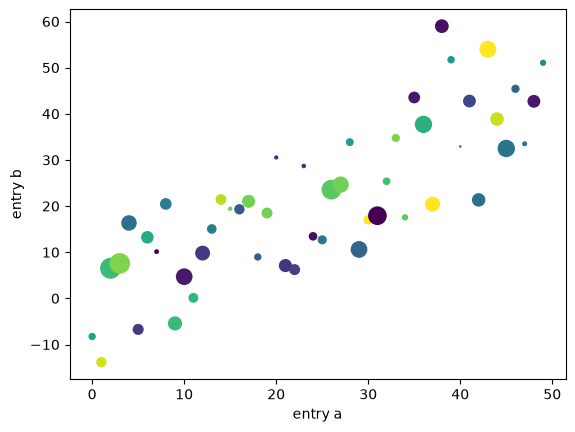

In [5]:
np.random.seed(19)  # seed the random number generator.
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

fig, ax = plt.subplots()
ax.scatter('a', 'b',c='c',s='d', data=data)
ax.set_xlabel('entry a')
ax.set_ylabel('entry b')

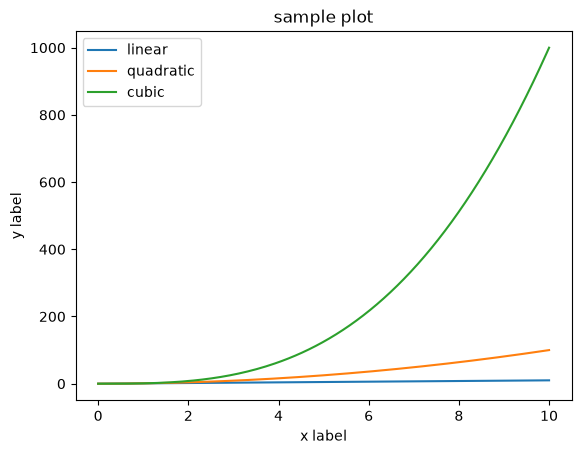

In [6]:
x = np.linspace(0,10,200)
fig, ax = plt.subplots()
ax.plot(x,x,label='linear')
ax.plot(x,x**2, label='quadratic')
ax.plot(x,x**3,label='cubic')
ax.set_xlabel('x label')
ax.set_ylabel('y label')
ax.set_title('sample plot')
ax.legend()

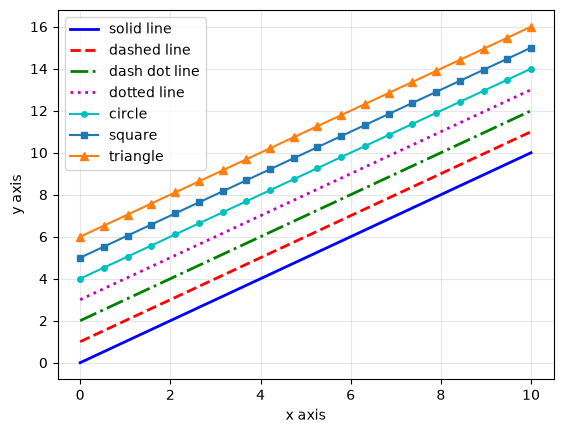

In [9]:
y = np.linspace(0,10,20)
fig = plt.subplots()
plt.plot(y,y,'b-',label='solid line', linewidth=2)
plt.plot(y,y+1, 'r--', label='dashed line', linewidth=2)
plt.plot(y,y+2, 'g-.', label='dash dot line', linewidth=2)
plt.plot(y,y+3, 'm:', label='dotted line', linewidth=2)
plt.plot(y,y+4, 'co-', label='circle', markersize=4)
plt.plot(y,y+5, 's-', label='square', markersize=4)
plt.plot(y,y+6, '^-', label='triangle', markersize=6)

plt.legend()
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.grid(alpha=0.3)

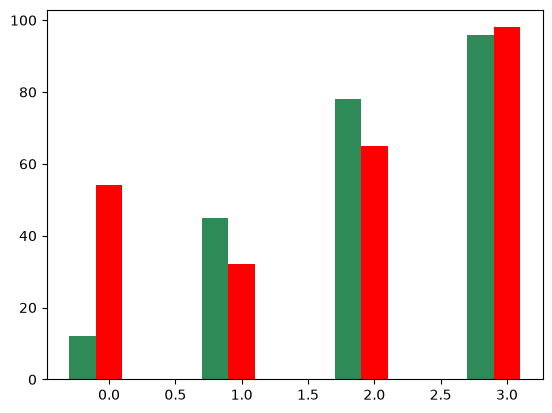

In [27]:
# bar chart
cate = ['A','B','C','D']
grp1 = [12,45,78,96]
grp2 = [54,32,65,98]

x_label = np.arange(len(cate))
width = 0.2
plt.bar(x_label - width, grp1, width, color='seagreen')
plt.bar(x_label, grp2, width, color='red')
plt.show()

In [29]:
import numpy as np
import pandas as pd

np.random.seed(91)

wetlands = [
    "East Kolkata",
    "Nalban",
    "Santragachi",
    "Purbasthali",
    "Bethuadahari"
]

species = [
    "Bar-headed Goose",
    "Northern Shoveler",
    "Common Teal",
    "Little Egret",
    "Black-winged Stilt",
    "Pied Kingfisher",
    "Purple Swamphen"
]

dates = pd.date_range("2025-10-01", "2026-01-31", freq="D")

rows = []

for date in dates:
    for wetland in wetlands:
        # Not every species is observed at every wetland/date
        n_species = np.random.randint(3, 7)
        sampled_species = np.random.choice(
            species,
            size=n_species,
            replace=False
        )

        for sp in sampled_species:
            rows.append({
                "date": date,
                "wetland": wetland,
                "species": sp,
                "individuals": np.random.poisson(
                    np.random.uniform(8, 50)
                ),
                "observation_hours": np.random.uniform(1, 5)
            })

birds = pd.DataFrame(rows)

# Introduce missing observations
idx = np.random.choice(
    birds.index,
    size=30,
    replace=False
)

birds.loc[idx, "individuals"] = np.nan

birds.head()

,date,wetland,species,individuals,observation_hours
0,2025-10-01,East Kolkata,Black-winged Stilt,46.0,2.283253
1,2025-10-01,East Kolkata,Little Egret,35.0,1.786430
2,2025-10-01,East Kolkata,Bar-headed Goose,19.0,2.847342
3,2025-10-01,East Kolkata,Northern Shoveler,30.0,3.420595
4,2025-10-01,East Kolkata,Pied Kingfisher,9.0,4.672775


In [80]:
month_wise = birds.groupby('wetland')['individuals'].sum()
area_wise = birds.groupby('month')['individuals'].sum()

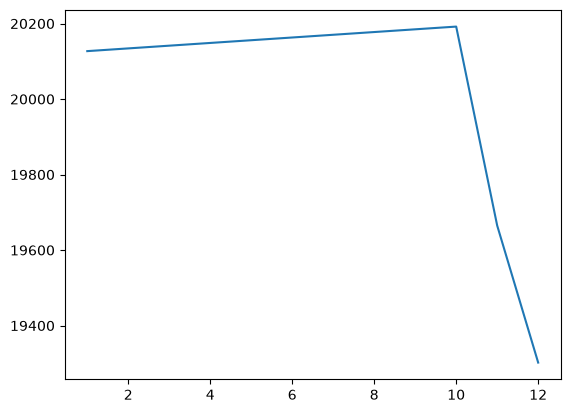

In [88]:
fig, ax = plt.subplots()
# ax.plot(
#     month_wise.index,
#     month_wise.values
# )
ax.plot(
    area_wise.index,
    area_wise.values
)
plt.show()